# Building P-P plots


**Workflow overview**
Generate tapered LISA noise with gaps.
Run MCMC with your normalization factor.
Do 50 independent realizations in parallel.
Compute the posterior medians.
Produce P–P plots for acceleration and readout noise.


## 1. Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import ligo.skymap.plot
from scipy import signal
from scipy.signal import welch
from scipy.signal.windows import tukey
from multiprocessing import get_context, cpu_count

from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import ProbDistContainer, uniform_dist

from eryn.utils import SearchConvergeStopping
from eryn.backends import HDFBackend
from eryn.moves import StretchMove
#from lisa_gap import GapMaskGenerator


%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 100

CHANNEL_NAMES = ['X', 'Y', 'Z']
CHANNEL_COLORS = ['k', 'r--', 'y']
np.random.seed(800)

## 2. Configuration

In [3]:
class Config:
    # --- Backend / output ---
    DELETE_BACKEND   = True
    BACKEND_FILE     = 'PE_TM_OMS_GB_simplified_noises.h5'
    PLOT_DIR         = 'plots'

    # --- MCMC ---
    N_WALKERS          = 20
    N_TEMPS            = 5
    T_MAX              = np.inf
    N_STEPS            = 500
    N_STEPS_SIGNAL     = 9000
    UPDATE_ITERATIONS_SIGNAL  = 8999
    THIN_BY            = 1
    BURN               = 0
    UPDATE_ITERATIONS  = 499
    COORDS_FROM_PRIOR  = True
    USE_GPU            = False

    # --- Observation / sampling ---
    f_min     = 2.5e-5   # Hz
    f_max     = 2.0e-2   # Hz
    T_OBS     = 1.0 / f_min          # seconds
    DT        = 1.0 / (2 * f_max)    # seconds
    SIDEREAL_YEAR = 365.25636 * 86400  # seconds

    # --- Physical constants ---
    C          = 299_792_458.0   # m/s
    WAVELENGTH = 1064.5e-9       # m

    # --- Noise / prior ---
    AVERAGE_ARMLENGTH    = 8.322688660167833   # light-seconds
    PARAM_SIGNAL   = np.array([1e-21, 3e-3])
    PARAM_NOISE_AMP   = np.array([2.4e-15, 6.35e-12])
    PARAM_TOT =  np.array([1e-21, 3e-3, 2.4e-15, 6.35e-12])
    PARAM_INDICES_TO_FIT = [0, 1]
    PRIOR_FACTOR  = 1e2    # era 1e9 → troppo largo
    INIT_SPREAD   = 0.1    # era 0.01 → troppo stretto


print('Configuration loaded.')
print(f'  T_obs = {Config.T_OBS / Config.SIDEREAL_YEAR:.2f} yr')
print(f'  dt    = {Config.DT} s')
print(f'  f_min = {Config.f_min:.2e} Hz,  f_max = {Config.f_max:.2e} Hz')

Configuration loaded.
  T_obs = 0.00 yr
  dt    = 25.0 s
  f_min = 2.50e-05 Hz,  f_max = 2.00e-02 Hz


## 3. Noise Model

The two free parameters are:
- `acc_level` – test-mass acceleration noise amplitude
- `readout_isi` – ISI readout noise amplitude

These enter the TDI X auto-PSD (`psd_xx`) and cross-PSD (`csd_xy`) between any pair of channels.

In [4]:
def compute_noise_psd_csd(freq, acc_level, readout_isi, armlength):
    """Return (psd_xx, csd_xy) for TDI X/Y/Z channels."""
    omega = 2 * np.pi * freq
    T     = armlength
    nu0   = Config.C / Config.WAVELENGTH

    disp_2_ffd = (omega / Config.WAVELENGTH / nu0) ** 2
    acc_2_ffd  = (1 / (Config.WAVELENGTH * omega) / nu0) ** 2

    tm_noise       = acc_level   ** 2 * (1 + (0.4e-3 / freq) ** 2) * (1 + (freq / 8e-3) ** 4)
    readout_noise  = readout_isi ** 2 * (1 + (2e-3 / freq) ** 4)

    psd_xx = (256 * np.cos(2*np.pi*freq*T)**2 * np.sin(2*np.pi*freq*T)**4
              * ((3 + np.cos(2*T*2*np.pi*freq)) * acc_2_ffd * tm_noise
                 + disp_2_ffd * readout_noise))
    csd_xy = (-16 * np.sin(2*np.pi*freq*T) * np.sin(4*np.pi*freq*T)**3
              * (4 * acc_2_ffd * tm_noise + disp_2_ffd * readout_noise))
    return psd_xx, csd_xy


def build_csd_matrix(freqs, noise_params=None):
    """Build the (n_freqs, 3, 3) CSD matrix for the three TDI channels."""
    if noise_params is None:
        noise_params = Config.PARAM_NOISE_AMP
    psd, csd_cross = compute_noise_psd_csd(
        freqs,
        acc_level=noise_params[0],
        readout_isi=noise_params[1],
        armlength=Config.AVERAGE_ARMLENGTH,
    )
    n_freqs = len(freqs)
    mat = np.zeros((n_freqs, 3, 3), dtype=complex)
    for i in range(3):
        mat[:, i, i] = psd
    for (i, j) in [(0,1), (1,2), (0,2)]:
        mat[:, i, j] = mat[:, j, i] = csd_cross
    return mat

## 4. Data Generation noise and signal

In [5]:
def generate_correlated_noise_fft(freqs, N, dt, csd_matrix):
    """Draw correlated Gaussian noise in the frequency domain via Cholesky."""
    n_channels = csd_matrix.shape[1]
    n_freqs    = len(freqs)
    cov_fft    = csd_matrix * N / (2 * dt)
    L          = np.linalg.cholesky(cov_fft)
    z = (np.random.normal(0, 1/np.sqrt(2), (n_freqs, n_channels))
         + 1j * np.random.normal(0, 1/np.sqrt(2), (n_freqs, n_channels)))
    return np.einsum('fij,fj->fi', L, z)

def generate_signal(t, A=Config.PARAM_SIGNAL[0], f=Config.PARAM_SIGNAL[1]):
    """
    Generate a monochromatic sinusoidal signal  s(t) = A * sin(2π f t).

    Parameters
    ----------
    t : array
        Time samples [s], e.g. np.arange(N) * dt
    A : float
        Amplitude  (default 1e-21, GW strain order-of-magnitude)
    f : float
        Frequency [Hz]  (default 3e-3 Hz = 3 mHz, in the LISA band)

    Returns
    -------
    
    signal : ndarray, shape (len(t), 3)
        Signal injected into all three TDI channels (X, Y, Z).
    """
    s = A * np.sin(2 * np.pi * f * t)
    return np.column_stack([s, s, s])   # broadcast to 3 channels

In [6]:
# Build time/frequency grids
N          = int(Config.T_OBS / Config.DT)
Config.T_OBS = Config.DT * N          # snap to exact grid
t          = np.arange(N) * Config.DT
freqs      = np.fft.rfftfreq(N, Config.DT)
freqs[0]   = freqs[1]                 # avoid DC singularity

print(f'N = {N} samples,  T_obs = {Config.T_OBS / Config.SIDEREAL_YEAR:.2f} yr')
print(f'n_freqs = {len(freqs)},  freq range = [{freqs[1]:.2e}, {freqs[-1]:.2e}] Hz')

# Generate clean (gap-free) data
csd_matrix     = build_csd_matrix(freqs)
fft_data_no_gaps = generate_correlated_noise_fft(freqs, N, Config.DT, csd_matrix)
time_data_no_gaps = np.fft.irfft(fft_data_no_gaps, n=N, axis=0)

N = 1600 samples,  T_obs = 0.00 yr
n_freqs = 801,  freq range = [2.50e-05, 2.00e-02] Hz


## 5. Likelihood Function

In [7]:
def log_likelihood(log_params, data, freqs, dt, N, W2, subset=1):
    """
    Log-likelihood for correlated TDI noise.

    Parameters
    ----------
    log_params : array (n_samples, 2)
        Log of [acc_level, readout_isi] for each walker sample.
    data   : array (n_freqs, 3)  – FFT data for X/Y/Z
    freqs  : array (n_freqs,)
    dt     : float – sample cadence [s]
    N      : int   – number of time samples
    W2     : float – window normalisation factor
    subset : int   – sub-batch stride (for vectorised evaluation)
    """
    params = np.exp(log_params)
    if params.ndim == 1:
        params = params[np.newaxis, :]

    n_samples = params.shape[0]
    inds = np.arange(0, n_samples + 1, subset)
    if inds[-1] < n_samples:
        inds = np.append(inds, n_samples)

    log_like_all = []
    for start, end in zip(inds[:-1], inds[1:]):
        for A, B in params[int(start):int(end)]:
            psd_s, csd_r = compute_noise_psd_csd(
                freqs, acc_level=A, readout_isi=B,
                armlength=Config.AVERAGE_ARMLENGTH
            )
            det_sigma = (psd_s - csd_r) ** 2 * (psd_s + 2 * csd_r)
            if np.any(det_sigma <= 0) or np.any(psd_s <= 0):
                log_like_all.append(-np.inf)
                continue

            inv_diag = (psd_s ** 2 - csd_r ** 2) / det_sigma
            inv_off  = (csd_r ** 2 - psd_s * csd_r) / det_sigma

            d0, d1, d2 = data[:, 0]/W2, data[:, 1]/W2, data[:, 2]/W2
            quad = (
                inv_diag * (np.abs(d0)**2 + np.abs(d1)**2 + np.abs(d2)**2)
                + 2 * inv_off.real * (
                    (d0 * d1.conj()).real
                    + (d0 * d2.conj()).real
                    + (d1 * d2.conj()).real
                )
            )
            log_det  = np.sum(np.log(det_sigma))
            log_like_all.append(-2*dt/N * np.sum(quad) - log_det)

    return np.array(log_like_all)

## 7. MCMC Setup

Shared objects (priors, moves, stopping criterion, pool) reused across all experiments.

In [8]:
# Branch / dimension specification
branch_names = ['noise']
ndims        = {'noise': 2}
nleaves_max  = {'noise': 1}
nleaves_min  = {'noise': 1}

# Uniform priors in log-space
params_to_fit = Config.PARAM_NOISE_AMP[Config.PARAM_INDICES_TO_FIT]
priors_dict   = {
    i: uniform_dist(
        np.log(params_to_fit[i] / Config.PRIOR_FACTOR),
        np.log(params_to_fit[i] * Config.PRIOR_FACTOR),
    )
    for i in range(len(params_to_fit))
}
priors = {'noise': ProbDistContainer(priors_dict)}

# Initial coordinates drawn from prior
coords = {'noise': priors['noise'].rvs(
    size=(Config.N_TEMPS, Config.N_WALKERS, nleaves_max['noise']))}
inds   = {'noise': np.ones(
    (Config.N_TEMPS, Config.N_WALKERS, nleaves_max['noise']), dtype=bool)}

# Sampler utilities
moves = [StretchMove(gibbs_sampling_setup='noise', live_dangerously=False)]
stop  = SearchConvergeStopping(n_iters=5, diff=0.01, verbose=True)

# Multiprocessing pool
n_cpus = cpu_count()
pool   = get_context('fork').Pool(n_cpus)
print(f'Using {n_cpus} CPU cores.')


def run_mcmc(fft_data, normalization_factor=1.0, label=''):
    """Convenience wrapper: initialise, run and return an EnsembleSampler."""
    if Config.DELETE_BACKEND and os.path.exists(Config.BACKEND_FILE):
        os.remove(Config.BACKEND_FILE)
        print(f"[{label}] Backend eliminato: '{Config.BACKEND_FILE}'")
    sampler = EnsembleSampler(
        Config.N_WALKERS, ndims, log_likelihood, priors,
        args=[fft_data, freqs, Config.DT, N, normalization_factor],
        tempering_kwargs=dict(ntemps=Config.N_TEMPS, Tmax=Config.T_MAX),
        moves=moves, rj_moves=False, provide_groups=False,
        nleaves_max=nleaves_max, nleaves_min=nleaves_min,
        branch_names=branch_names, pool=pool,
        update_iterations=Config.UPDATE_ITERATIONS,
        #update_fn=update_diagnostics,
        #stopping_fn=stop,
        nbranches=len(branch_names), vectorize=True,
        backend=Config.BACKEND_FILE,
    )
    log_p = sampler.compute_log_prior(coords, inds=inds)
    log_l = sampler.compute_log_like(coords, inds=inds, logp=log_p)[0]
    state = State(coords, inds=inds, log_like=log_l, log_prior=log_p)
    sampler.run_mcmc(state, Config.N_STEPS,
                     burn=Config.BURN, progress=True, thin_by=Config.THIN_BY)
    print(f'[{label}] MCMC complete.')
    return sampler


def compute_window_correction(window):
    """Return RMS normalisation factor W2 for a window / taper array."""
    return np.sqrt(np.sum(window ** 2) / len(window))


def extract_posterior_median(sampler, skip=500):
    """Return linear-scale posterior medians (acc_level, readout_isi)."""
    samples = sampler.get_chain()['noise'][-skip:, 0].reshape(-1, 2)
    return np.median(np.exp(samples), axis=0)


def extract_posterior(sampler, skip=500):
    """Return linear-scale posterior medians (acc_level, readout_isi)."""
    samples = sampler.get_chain()['noise'][-skip:, 0].reshape(-1, 2)
    return np.exp(samples)

Using 10 CPU cores.


Process ForkPoolWorker-7:
Process ForkPoolWorker-10:
Process ForkPoolWorker-1:
Process ForkPoolWorker-4:
Process ForkPoolWorker-6:
Process ForkPoolWorker-5:
Process ForkPoolWorker-9:
Process ForkPoolWorker-8:
Process ForkPoolWorker-3:
Process ForkPoolWorker-2:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/murmar/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/murmar/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/murmar/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/murmar/opt/anaconda3

# Whiten correlated TDI data in the frequency domain

In [9]:
def whiten_noise_fft(fft_data, freqs, noise_params=None):
    """
    Whiten correlated TDI data in the frequency domain.

    Applies (L_f)^{-1} at each frequency bin, where L_f is the Cholesky
    factor of the 3×3 CSD matrix.

    Parameters
    ----------
    fft_data    : (n_freqs, 3) complex array
    freqs       : (n_freqs,) array
    noise_params: (2,) array or None  – defaults to Config.PARAM_NOISE_AMP
    """
    csd_mat = build_csd_matrix(freqs, noise_params)
    out     = np.zeros_like(fft_data, dtype=complex)
    for i in range(len(freqs)):
        L       = np.linalg.cholesky(csd_mat[i])
        out[i]  = np.linalg.solve(L, fft_data[i])   # L_inv @ d
    return out

## 8. Experiment A – No Gaps

Baseline: run MCMC directly on the clean data.

In [10]:
ensemble_no_gaps_temp = run_mcmc(fft_data_no_gaps, normalization_factor=1.0,
                            label='no-gaps')

from copy import deepcopy
ensemble_no_gaps = deepcopy(ensemble_no_gaps_temp)

[no-gaps] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:14<00:00, 33.89it/s]

[no-gaps] MCMC complete.


In [34]:
# Apply gap in-place on a copy
time_data_with_gaps = time_data_no_gaps.copy()
gap_samples = int(3600 / Config.DT)
gap_start   = 700
time_data_with_gaps[gap_start : gap_start + gap_samples, :] = 0
fft_data_with_gaps = np.fft.rfft(time_data_with_gaps, n=N, axis=0)

In [12]:
ensemble_with_gaps = run_mcmc(fft_data_with_gaps, normalization_factor=1.0,
                              label='naive-gap')

[naive-gap] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:11<00:00, 44.38it/s]

[naive-gap] MCMC complete.


## 10. Gap Mask Generation

Create a ficticious gap which is 1 outside the gapped region and 0 inside. We use a gaussian function to allow for smooter tapering. The results looks to be correct with a normalization factor

In [13]:
def smooth_gap_taper(mask, N_taper, kind="gaussian"):
    w = mask.astype(float)
    N = len(mask)

    # find contiguous gap segments
    diff = np.diff(mask.astype(int))
    gap_starts = np.where(diff == -1)[0] + 1
    gap_ends   = np.where(diff ==  1)[0] + 1

    if mask[0] == 0:
        gap_starts = np.r_[0, gap_starts]
    if mask[-1] == 0:
        gap_ends = np.r_[gap_ends, N]

    if kind == "gaussian":
        sigma = N_taper / 8  # gentle, adjustable

        for s, e in zip(gap_starts, gap_ends):
            # left edge
            for k in range(1, N_taper + 1):
                i = s - k
                if i >= 0 and mask[i] == 1:
                    w[i] = 1 - np.exp(-0.5 * (k / sigma) ** 2)

            # right edge
            for k in range(1, N_taper + 1):
                i = e + k - 1
                if i < N and mask[i] == 1:
                    w[i] = 1 - np.exp(-0.5 * (k / sigma) ** 2)

    return w

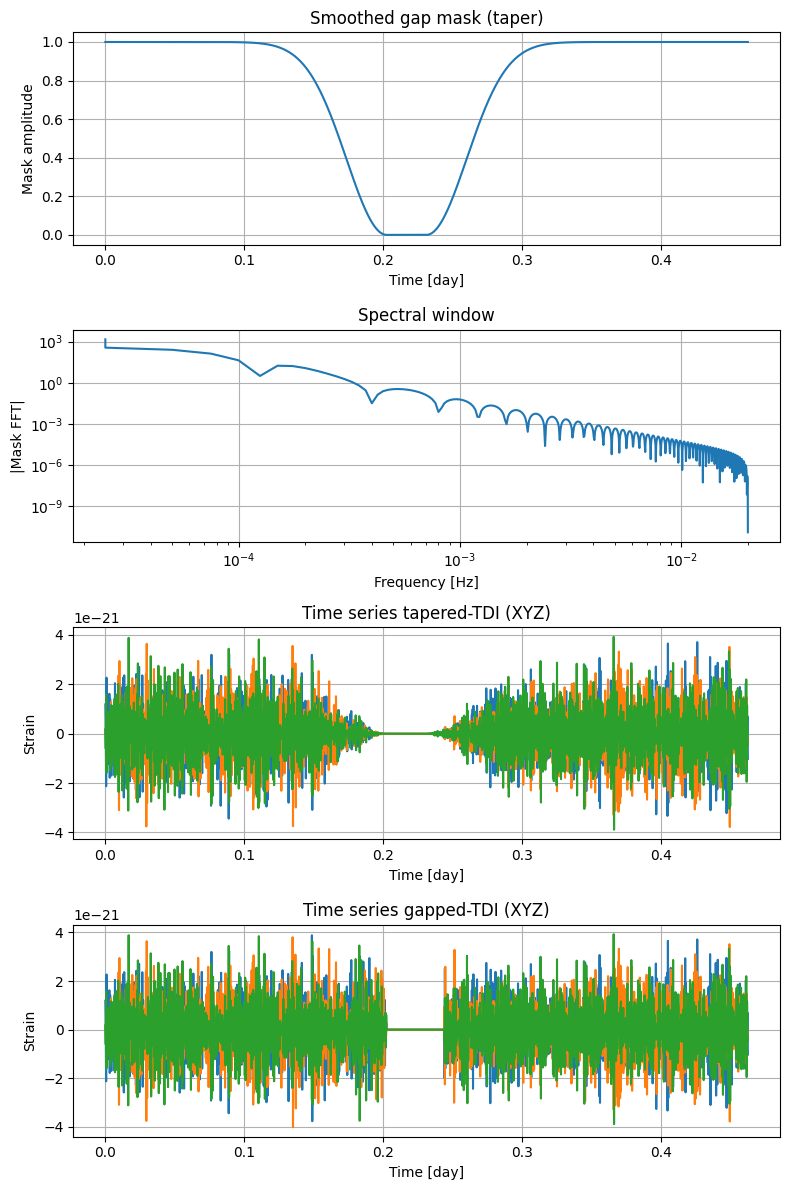

Mask duty cycle: 0.781
Window normalisation factor W2 = 0.857657


In [37]:
mask = np.ones(len(time_data_with_gaps[:,0]))
mask[700:800] = 0
smooth_taper = smooth_gap_taper(mask, N_taper=800)

N = len(smooth_taper)
smooth_taperfft = np.fft.rfft(smooth_taper)

normalization_factor = compute_window_correction(smooth_taper)


time_data_tapered =time_data_no_gaps * smooth_taper[:, np.newaxis]


fig, ax = plt.subplots(4,1, figsize=(8, 12))

# Time domain mask
ax[0].plot(t/86400, smooth_taper)
ax[0].set(xlabel='Time [day]', ylabel='Mask amplitude',
          title='Smoothed gap mask (taper)')
ax[0].grid(True)

# Frequency domain window
ax[1].loglog(freqs, np.abs(smooth_taperfft/normalization_factor))
ax[1].set(xlabel='Frequency [Hz]', ylabel='|Mask FFT|',
          title='Spectral window')
ax[1].grid(True)


# Time series

ax[2].plot(t / 86400, time_data_tapered[:,0])
ax[2].plot(t / 86400, time_data_tapered[:,1])
ax[2].plot(t / 86400, time_data_tapered[:,2])
ax[2].set(xlabel='Time [day]', ylabel='Strain', title='Time series tapered-TDI (XYZ)')
ax[2].grid(True)

ax[3].plot(t / 86400, time_data_with_gaps[:,0])
ax[3].plot(t / 86400, time_data_with_gaps[:,1])
ax[3].plot(t / 86400, time_data_with_gaps[:,2])
ax[3].set(xlabel='Time [day]', ylabel='Strain', title='Time series gapped-TDI (XYZ)')
ax[3].grid(True)

plt.tight_layout()
plt.show()


print(f'Mask duty cycle: {smooth_taper.mean():.3f}')
print(f'Window normalisation factor W2 = {normalization_factor:.6f}')

## 11. Experiment C – Tapered Gap Mask with normalization window

Look a bit better including the normalization but still not OK

In [15]:
import numpy as np
import matplotlib.pyplot as plt
#from multiprocessing import Pool, cpu_count

# --- Settings ---



# ---------------------------------------------------
# --- single realization function ---
# ---------------------------------------------------

def run_withened_time_series(seed,normalization_factor,with_gaps = True):
    """
    Run one realization:
      - generate tapered noise with gaps
      - run MCMC with normalization
      - return posterior samples
    """
    # --- generate correlated noise ---
    csd_matrix     = build_csd_matrix(freqs)
    fft_data_no_gaps = generate_correlated_noise_fft(freqs, N, Config.DT, csd_matrix)
    noise_time = np.fft.irfft(fft_data_no_gaps, n=N, axis=0)
    time_data_tapered =noise_time * smooth_taper[:, np.newaxis]

    # --- apply smooth taper / gap mask ---

    # --- FFT for MCMC ---
    if with_gaps:
       fft_data_tapered = np.fft.rfft(time_data_tapered,n=N,  axis=0)
    else:
       fft_data_tapered = np.fft.rfft(noise_time,n=N,  axis=0)

    # --- run MCMC ---
    ensemble = run_mcmc(
        fft_data_tapered,
        normalization_factor=normalization_factor,
    )

    # posterior samples
    acc_med, readout_med = extract_posterior_median(ensemble)
    print(f"Finished seed {seed}")
    
    whitened_tapered_fft  = whiten_noise_fft(fft_data_tapered, freqs,
                                                  noise_params=np.array([acc_med, readout_med]))
    whitened_tapered_time = np.fft.irfft(whitened_tapered_fft, n=N, axis=0)
    return acc_med, readout_med, whitened_tapered_time



def run_posteriors_extration(seed,normalization_factor,with_gaps = True):

    # --- generate correlated noise ---
    csd_matrix     = build_csd_matrix(freqs)
    fft_data_no_gaps = generate_correlated_noise_fft(freqs, N, Config.DT, csd_matrix)
    noise_time = np.fft.irfft(fft_data_no_gaps, n=N, axis=0)
    time_data_tapered =noise_time * smooth_taper[:, np.newaxis]

    # --- apply smooth taper / gap mask ---

    # --- FFT for MCMC ---
    if with_gaps:
       fft_data_tapered = np.fft.rfft(time_data_tapered,n=N,  axis=0)
    else:
       fft_data_tapered = np.fft.rfft(noise_time,n=N,  axis=0)

    # --- run MCMC ---
    ensemble = run_mcmc(
        fft_data_tapered,
        normalization_factor=normalization_factor,
    )

    # posterior samples
    acc = extract_posterior(ensemble)[:,0]
    readout = extract_posterior(ensemble)[:,1]

    return acc, readout

[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 37.47it/s]


[] MCMC complete.
Finished seed 95968
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 37.51it/s]


[] MCMC complete.
Finished seed 11886
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


...

[] MCMC complete.
Finished seed 13422
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 36.49it/s]


[] MCMC complete.
Finished seed 60106
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 36.13it/s]


[] MCMC complete.
Finished seed 15250


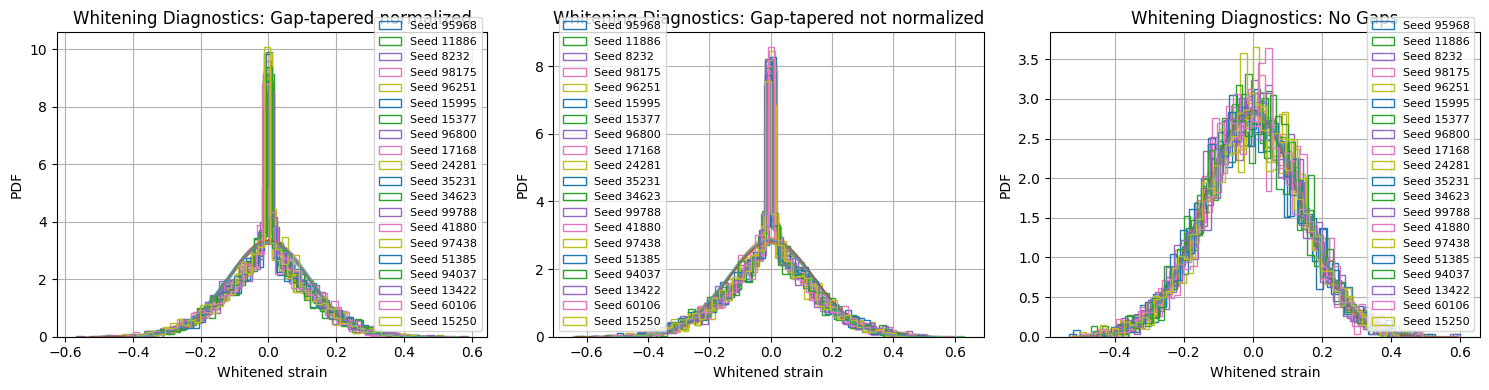

In [16]:
# ---------------------------------------------------
# --- main parallel execution ---
# ---------------------------------------------------

if __name__ == "__main__":

    import random

    seeds = random.sample(range(0, 100000), 20)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Define the three cases
    cases = [
        {"norm_factor": normalization_factor, "with_gaps": True, "label_prefix": "Gap-tapered normalized"},
        {"norm_factor": 1, "with_gaps": True, "label_prefix": "Gap-tapered not normalized"},
        {"norm_factor": 1, "with_gaps": False, "label_prefix": "No Gaps"},
    ]

    for ax, case in zip(axes, cases):
        for seed in seeds:
            # run your realization
            acc_med, readout_med, whitened_tapered_time = run_withened_time_series(
                seed,
                case["norm_factor"],
                with_gaps=case["with_gaps"]
            )
            # plot histogram of this seed (inside the seed loop!)
            ax.hist(
                whitened_tapered_time[:, 0],
                bins=50,
                density=True,
                histtype='step',
                alpha=1,
                label=f"Seed {seed}"
            )
            
            # normalized histogram
           # Gaussian fit
            mu = np.mean(whitened_tapered_time[:, 0])
            sigma = np.std(whitened_tapered_time[:, 0])

            x = np.linspace(min(whitened_tapered_time[:, 0]), max(whitened_tapered_time[:, 0]), 1000)
            pdf = 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2/(2*sigma**2))

            ax.plot(x, pdf,alpha=0.5,linewidth=1) #, label=f"Gaussian fit\nμ={mu:.3f}, σ={sigma:.3f}")


        # These should be **after all seeds are plotted**
        ax.set_xlabel("Whitened strain")
        ax.set_ylabel("PDF")
        ax.set_title(f"Whitening Diagnostics: {case['label_prefix']}")
        ax.legend(fontsize=8)
        ax.grid(True)

    plt.tight_layout()
    plt.show()

# do the P-P plots

## GAPS and normalization factor

In [17]:
# Select the case to analyze (Case A)
case = {"norm_factor": normalization_factor, "with_gaps": True, "label_prefix": "Taper-norm"}
# Storage for posterior samples of acc and readout
acc_list = []
readout_list = []

# Run realizations for all seeds
for seed in seeds:
    acc, readout = run_posteriors_extration(
        seed,
        case["norm_factor"],
        with_gaps=case["with_gaps"]
    )
    acc_list.append(acc)
    readout_list.append(readout)

# Convert to arrays: shape (n_seeds, n_samples)
acc_array = np.array(acc_list)
readout_array = np.array(readout_list)

[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 37.21it/s]


[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 37.10it/s]


[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


...

[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 36.19it/s]


[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 37.39it/s]

[] MCMC complete.


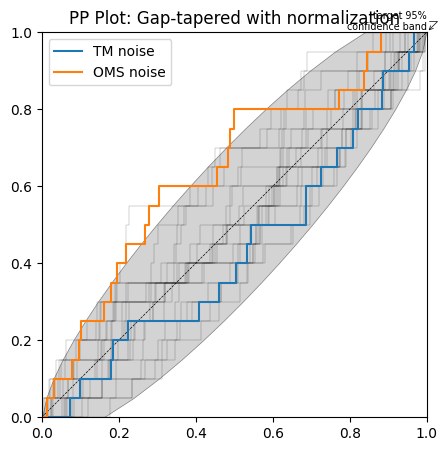

In [18]:
true_acc = Config.PARAM_NOISE_AMP[0]
true_readout =  Config.PARAM_NOISE_AMP[1]


# numero di esperimenti simulati
n_experiments = len(seeds)

percentiles_acc = []
percentiles_oms = []

for i in range(n_experiments):

    acc_samples = acc_array[i, :]
    oms_samples = readout_array [i, :]

    p_acc = np.mean(acc_samples < true_acc)
    p_oms = np.mean(oms_samples < true_readout)

    percentiles_acc.append(p_acc)
    percentiles_oms.append(p_oms)

percentiles_acc = np.array(percentiles_acc)
percentiles_oms = np.array(percentiles_oms)

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='pp_plot')

ax.add_confidence_band(n_experiments, alpha=0.95)
ax.add_diagonal()
ax.add_lightning(n_experiments, 20)

ax.add_series(percentiles_acc, label="TM noise")
ax.add_series(percentiles_oms, label="OMS noise")
ax.set_title("PP Plot: Gap-tapered with normalization")  # <--- ecco il titolo

plt.legend()
plt.show()



## Gaps without normalziation

In [19]:
# Select the case to analyze (Case A)
case = {"norm_factor": 1, "with_gaps": True, "label_prefix": "Case A"}
# Storage for posterior samples of acc and readout
acc_list = []
readout_list = []

# Run realizations for all seeds
for seed in seeds:
    acc, readout = run_posteriors_extration(
        seed,
        case["norm_factor"],
        with_gaps=case["with_gaps"]
    )
    acc_list.append(acc)
    readout_list.append(readout)

# Convert to arrays: shape (n_seeds, n_samples)
acc_array = np.array(acc_list)
readout_array = np.array(readout_list)

[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 36.95it/s]


[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 36.73it/s]


[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


...

[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:14<00:00, 34.48it/s]


[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:14<00:00, 33.81it/s]

[] MCMC complete.


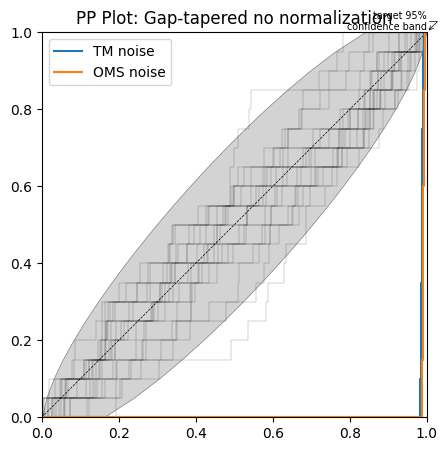

In [20]:
# numero di esperimenti simulati
n_experiments = len(seeds)

percentiles_acc = []
percentiles_oms = []

for i in range(n_experiments):

    acc_samples = acc_array[i, :]
    oms_samples = readout_array [i, :]

    p_acc = np.mean(acc_samples < true_acc)
    p_oms = np.mean(oms_samples < true_readout)

    percentiles_acc.append(p_acc)
    percentiles_oms.append(p_oms)

percentiles_acc = np.array(percentiles_acc)
percentiles_oms = np.array(percentiles_oms)

'''
plt.axvline(theta_true, color='k', linestyle='--', label="True value")
plt.legend()
plt.xlabel("Parameter value")
plt.ylabel("Density")
'''
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='pp_plot')

ax.add_confidence_band(n_experiments, alpha=0.95)
ax.add_diagonal()
ax.add_lightning(n_experiments, 20)

ax.add_series(percentiles_acc, label="TM noise")
ax.add_series(percentiles_oms, label="OMS noise")
ax.set_title("PP Plot: Gap-tapered no normalization")  # <--- ecco il titolo

plt.legend()
plt.show()


## Without GAP 

In [21]:
# Select the case to analyze (Case A)
case = {"norm_factor": 1, "with_gaps": False, "label_prefix": "Case A"}
# Storage for posterior samples of acc and readout
acc_list = []
readout_list = []

# Run realizations for all seeds
for seed in seeds:
    acc, readout = run_posteriors_extration(
        seed,
        case["norm_factor"],
        with_gaps=case["with_gaps"]
    )
    acc_list.append(acc)
    readout_list.append(readout)

# Convert to arrays: shape (n_seeds, n_samples)
acc_array = np.array(acc_list)
readout_array = np.array(readout_list)

[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:14<00:00, 35.24it/s]


[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:14<00:00, 34.64it/s]


[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


...

[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 36.44it/s]


[] MCMC complete.
[] Backend eliminato: 'PE_TM_OMS_GB_simplified_noises.h5'


100%|█████████████████████████████████████████| 500/500 [00:14<00:00, 35.65it/s]

[] MCMC complete.


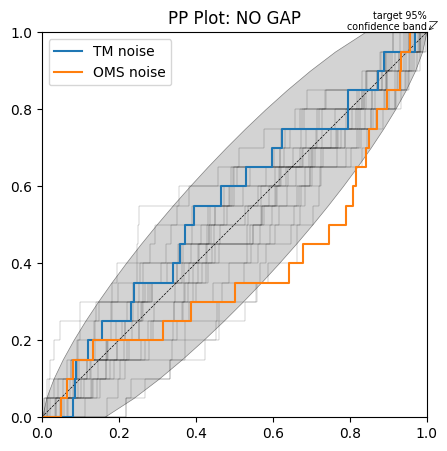

In [22]:
# numero di esperimenti simulati
n_experiments = len(seeds)

percentiles_acc = []
percentiles_oms = []

for i in range(n_experiments):

    acc_samples = acc_array[i, :]
    oms_samples = readout_array [i, :]

    p_acc = np.mean(acc_samples < true_acc)
    p_oms = np.mean(oms_samples < true_readout)

    percentiles_acc.append(p_acc)
    percentiles_oms.append(p_oms)

percentiles_acc = np.array(percentiles_acc)
percentiles_oms = np.array(percentiles_oms)

'''
plt.axvline(theta_true, color='k', linestyle='--', label="True value")
plt.legend()
plt.xlabel("Parameter value")
plt.ylabel("Density")
'''
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='pp_plot')

ax.add_confidence_band(n_experiments, alpha=0.95)
ax.add_diagonal()
ax.add_lightning(n_experiments, 20)

ax.add_series(percentiles_acc, label="TM noise")
ax.add_series(percentiles_oms, label="OMS noise")
ax.set_title("PP Plot: NO GAP")  # <--- ecco il titolo

plt.legend()
plt.show()


## 14. Cleanup

In [ ]:
pool.close()
pool.join()
print('Pool closed.')